<a href="https://colab.research.google.com/github/abino-w/-Food-Delivery-Business-Performance/blob/main/Food_Delivery_Business_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Business Performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/Day14_Food_Delivery_Visualization_Dataset.csv')

In [6]:
df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [7]:
df.shape

(360, 16)

In [8]:
df.dtypes

,0
Order_Batch_ID,object
Date,object
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

In [10]:
df.isnull().sum()

,0
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


In [11]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [12]:
df['Date']=pd.to_datetime(df['Date'])

In [13]:
df['City'].value_counts()

,count
City,
Delhi,53
Bengaluru,53
Hyderabad,48
Pune,42
Jaipur,42
Mumbai,41
Kochi,41
Chandigarh,40


In [14]:
df['Cuisine'].value_counts()

,count
Cuisine,
Healthy,68
Chinese,63
North Indian,61
Fast Food,58
Biryani,56
South Indian,54


In [15]:
df['Order_Channel'].value_counts()

,count
Order_Channel,
App,211
Website,77
Partner Platform,72


## 1. Trend Analysis Over Time (Line Plots)

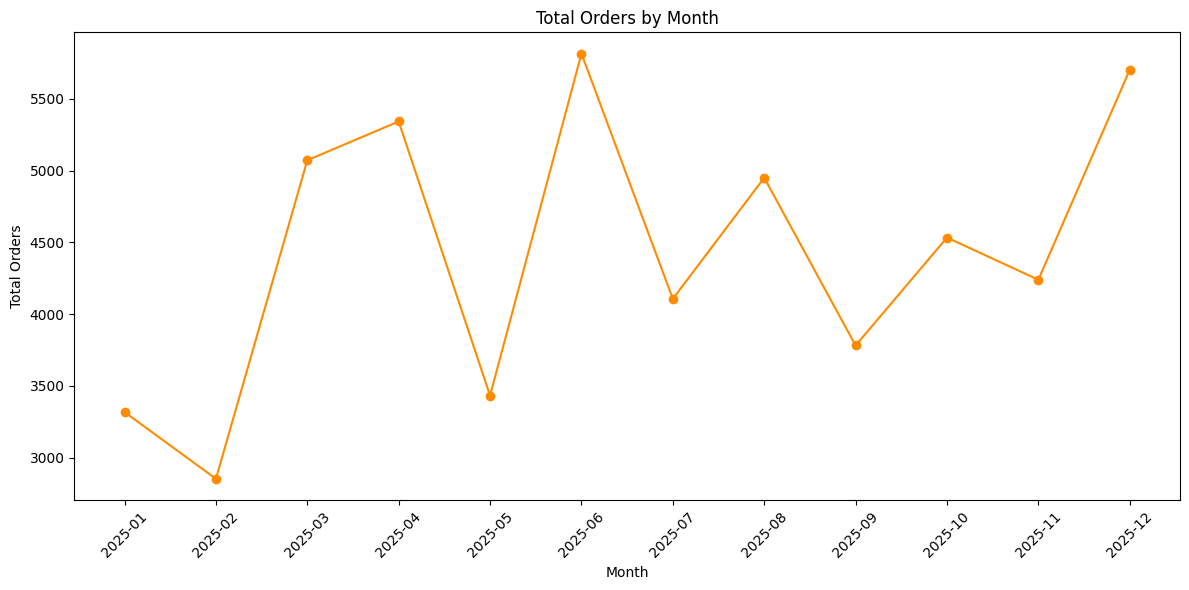

In [16]:
#monthly orders trend

monthly_orders=(df.groupby(df["Date"].dt.to_period("M"))["Orders"].sum().reset_index())
monthly_orders["Date"]=monthly_orders["Date"].astype(str)

fig, ax=plt.subplots(figsize=(12,6))

ax.plot(
    monthly_orders["Date"],
    monthly_orders["Orders"],
    marker='o',
    color='darkorange'
)

ax.set_title("Total Orders by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

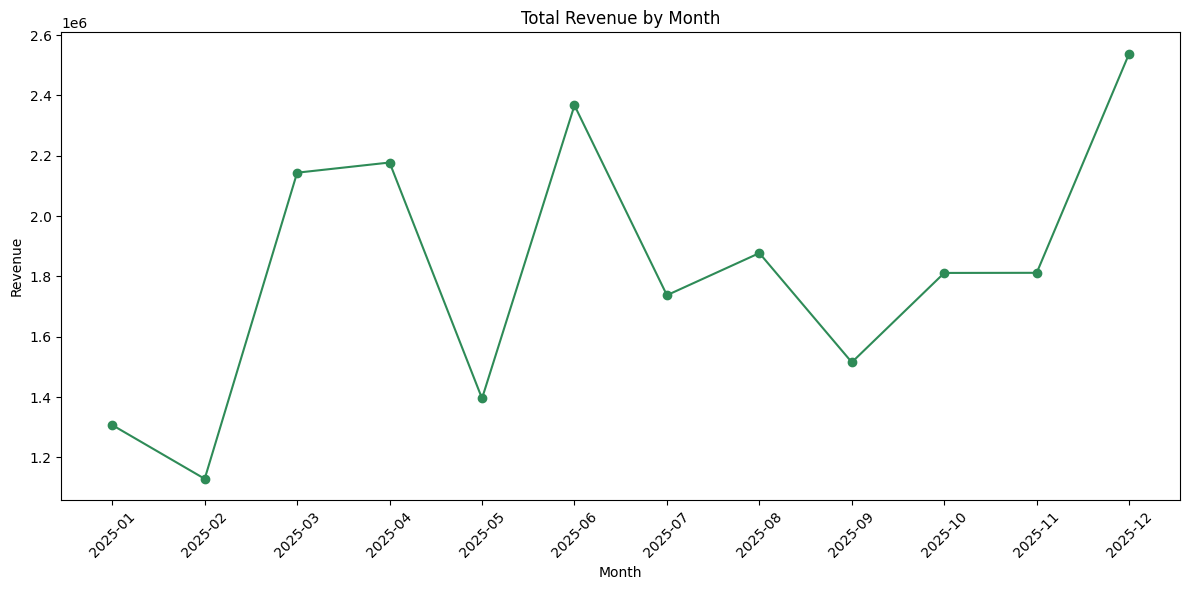

In [17]:
#monthly revenue trend

monthly_revenue=(df.groupby(df["Date"].dt.to_period("M"))["Revenue"].sum().reset_index())
monthly_revenue["Date"]=monthly_revenue["Date"].astype(str)

fig, ax=plt.subplots(figsize=(12,6))

ax.plot(
    monthly_revenue["Date"],
    monthly_revenue["Revenue"],
    marker='o',
    color='seagreen'
)

ax.set_title("Total Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Differences Between Cities and Cuisines (Bar Charts)

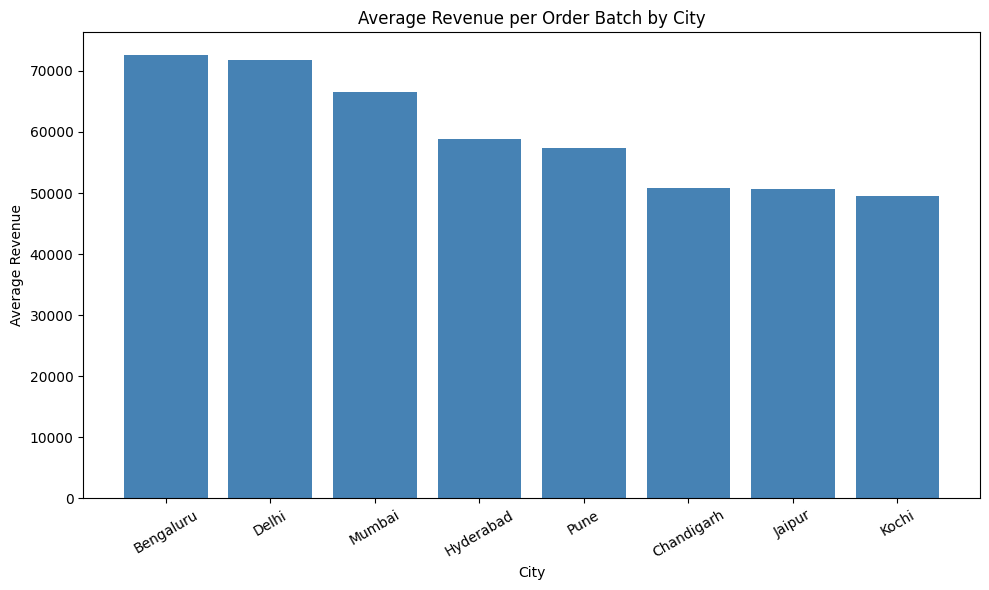

In [20]:
#average revenue by city

city_revenue=df.groupby("City")["Revenue"].mean().sort_values(ascending=False).reset_index()

fig, ax=plt.subplots(figsize=(10,6))

ax.bar(
    city_revenue["City"],
    city_revenue["Revenue"],
    color='steelblue'
)

ax.set_title("Average Revenue per Order Batch by City")
ax.set_xlabel("City")
ax.set_ylabel("Average Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

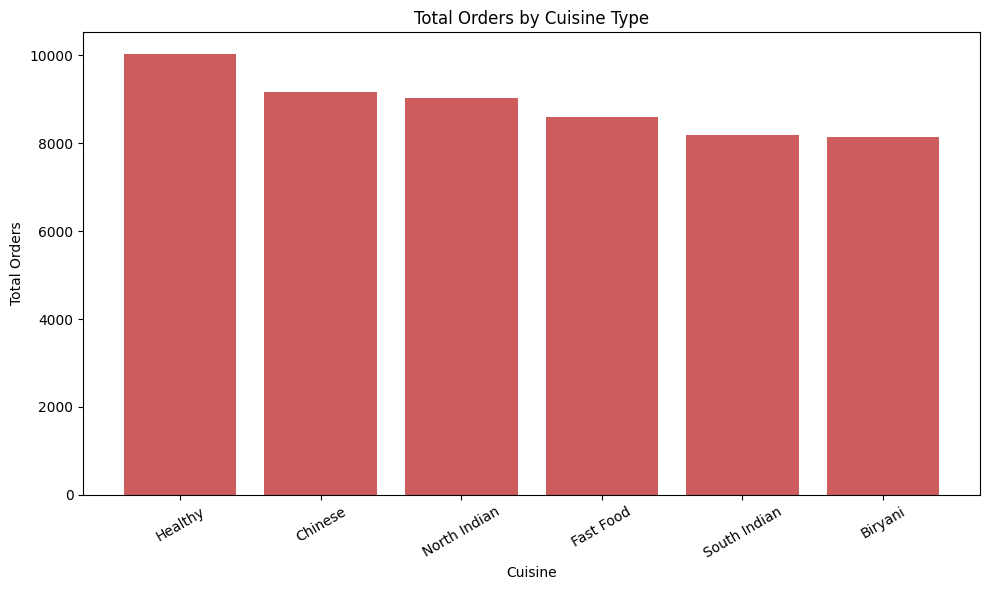

In [21]:
#total orders by cuisine

cuisine_orders=df.groupby("Cuisine")["Orders"].sum().sort_values(ascending=False).reset_index()

fig, ax=plt.subplots(figsize=(10,6))

ax.bar(
    cuisine_orders["Cuisine"],
    cuisine_orders["Orders"],
    color='indianred'
)

ax.set_title("Total Orders by Cuisine Type")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Total Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Relationships Between Variables (Scatter Plots)

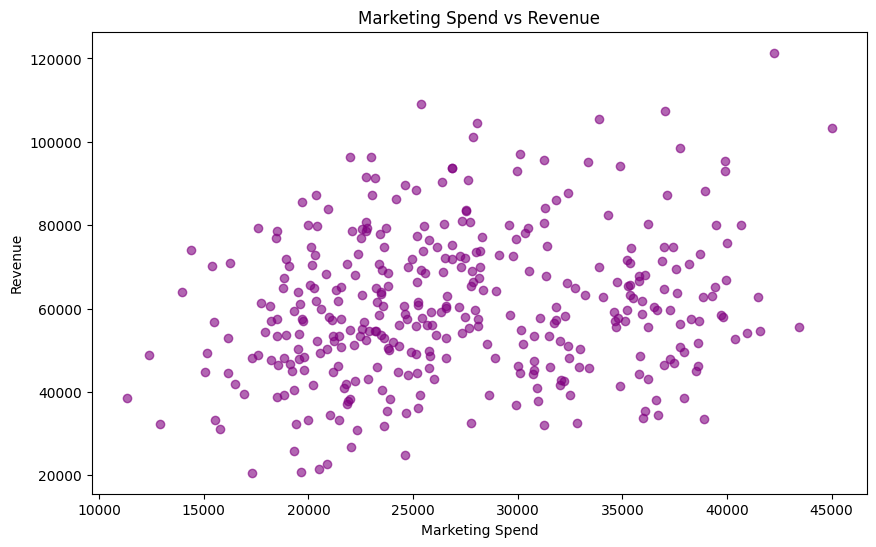

In [22]:
#marketing spend vs revenue

fig, ax=plt.subplots(figsize=(10,6))

ax.scatter(
    df["Marketing_Spend"],
    df["Revenue"],
    alpha=.6,
    color='purple'
)

ax.set_title("Marketing Spend vs Revenue")
ax.set_xlabel("Marketing Spend")
ax.set_ylabel("Revenue")
plt.show()

In [23]:
df[["Marketing_Spend","Revenue"]].corr()

,Marketing_Spend,Revenue
Marketing_Spend,1.000000,0.198127
Revenue,0.198127,1.000000


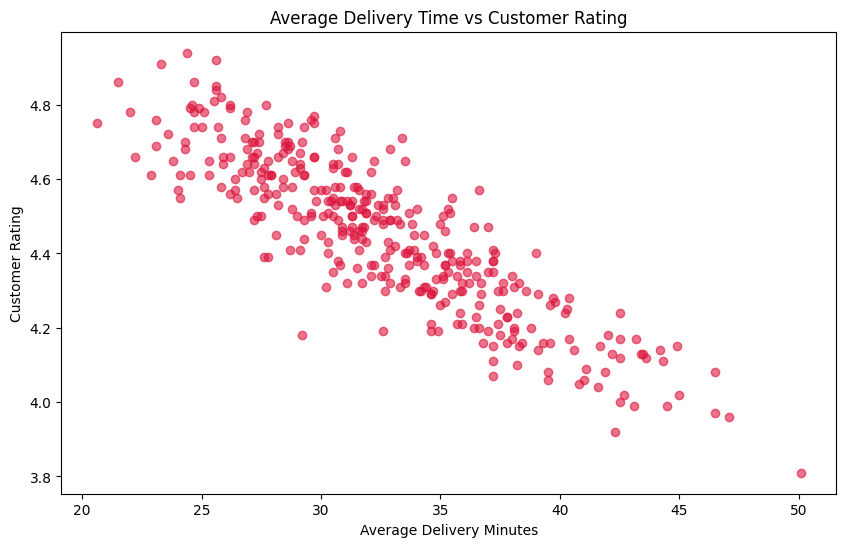

In [24]:
#delivery time vs customer rating

fig, ax=plt.subplots(figsize=(10,6))

ax.scatter(
    df["Avg_Delivery_Minutes"],
    df["Customer_Rating"],
    alpha=.6,
    color='crimson'
)

ax.set_title("Average Delivery Time vs Customer Rating")
ax.set_xlabel("Average Delivery Minutes")
ax.set_ylabel("Customer Rating")
plt.show()

In [25]:
df[["Avg_Delivery_Minutes","Customer_Rating"]].corr()

,Avg_Delivery_Minutes,Customer_Rating
Avg_Delivery_Minutes,1.000000,-0.875881
Customer_Rating,-0.875881,1.000000


## 4. Distribution Analysis (Histogram, Box Plot, Violin Plot)

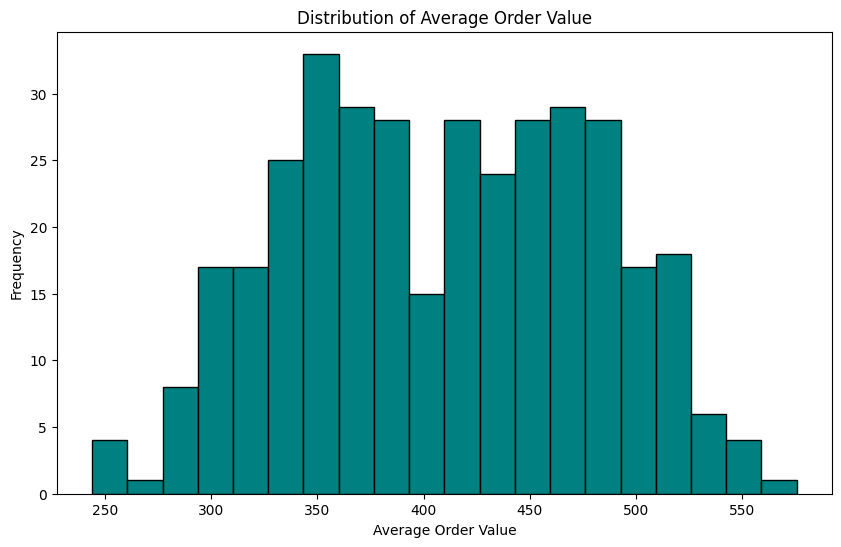

In [26]:
#histogram - distribution of average order value

fig, ax=plt.subplots(figsize=(10,6))

ax.hist(
    df["Average_Order_Value"],
    bins=20,
    color='teal',
    edgecolor='black'
)

ax.set_title("Distribution of Average Order Value")
ax.set_xlabel("Average Order Value")
ax.set_ylabel("Frequency")
plt.show()

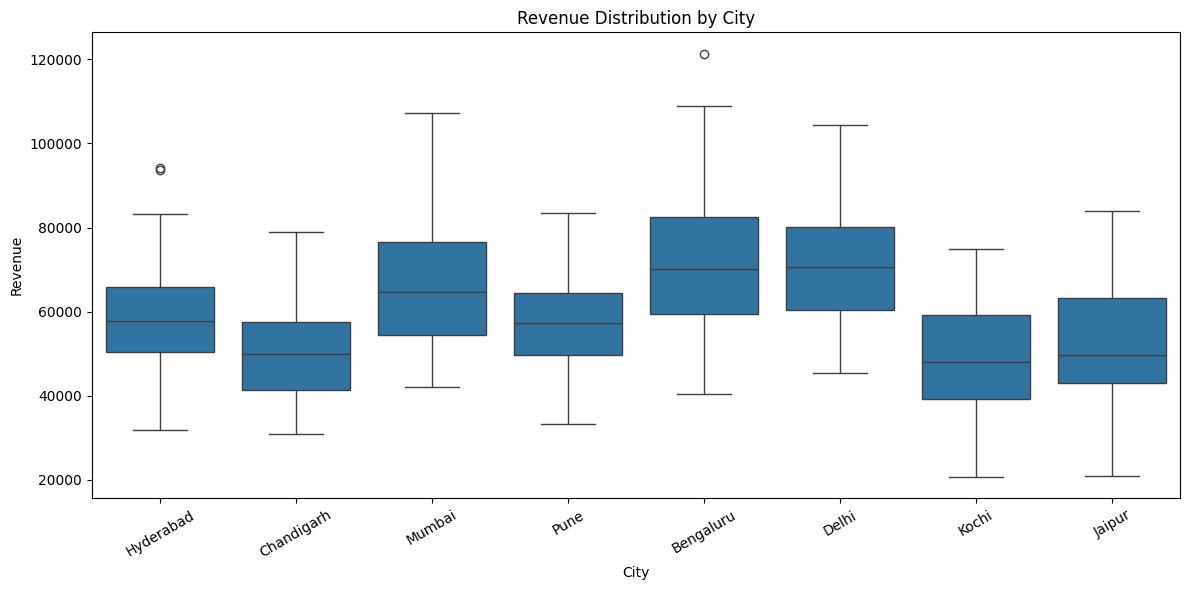

In [27]:
#box plot - revenue distribution by city

fig, ax=plt.subplots(figsize=(12,6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue",
    ax=ax
)

ax.set_title("Revenue Distribution by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

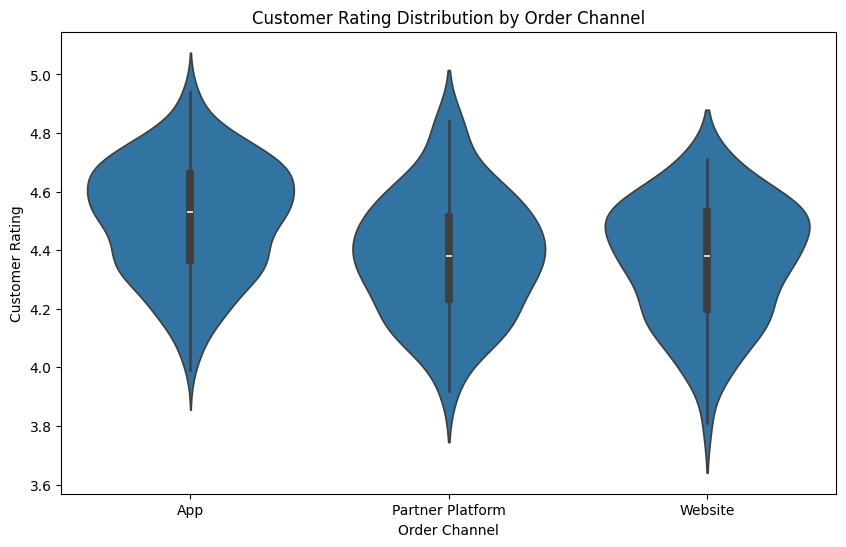

In [28]:
#violin plot - customer rating by order channel

fig, ax=plt.subplots(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Order_Channel",
    y="Customer_Rating",
    ax=ax
)

ax.set_title("Customer Rating Distribution by Order Channel")
ax.set_xlabel("Order Channel")
ax.set_ylabel("Customer Rating")
plt.show()

## 5. Effect of Weather and Order Channel on Performance (Count Plot, Bar Chart)

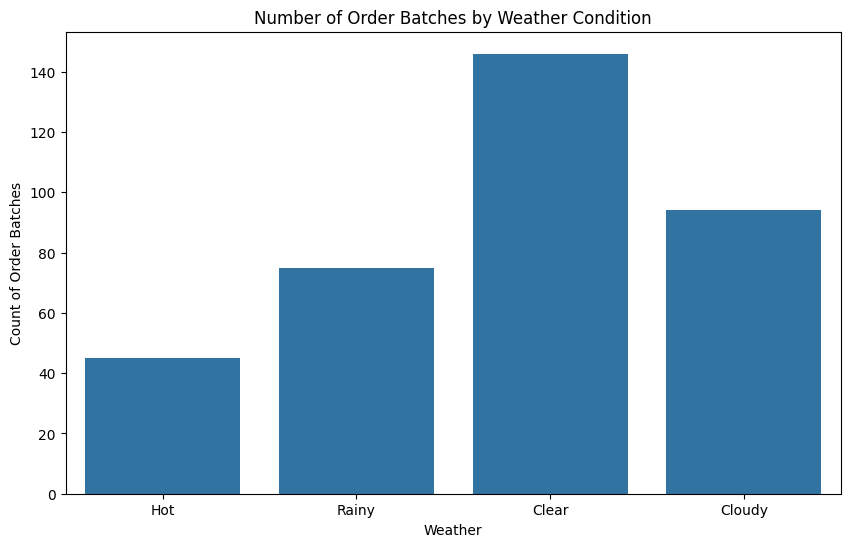

In [29]:
#count plot - number of order batches recorded per weather condition

fig, ax=plt.subplots(figsize=(10,6))

sns.countplot(
    data=df,
    x="Weather",
    ax=ax
)

ax.set_title("Number of Order Batches by Weather Condition")
ax.set_xlabel("Weather")
ax.set_ylabel("Count of Order Batches")
plt.show()

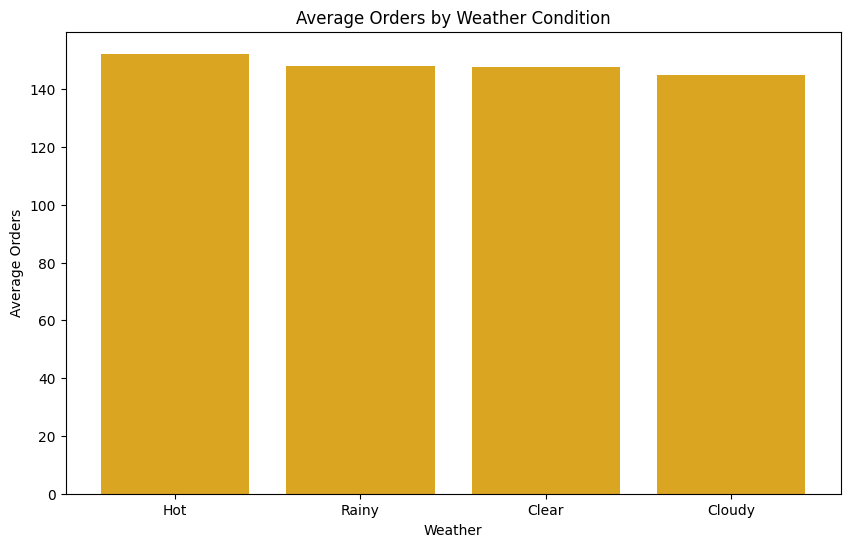

In [30]:
#bar chart - average orders by weather condition

weather_orders=df.groupby("Weather")["Orders"].mean().sort_values(ascending=False).reset_index()

fig, ax=plt.subplots(figsize=(10,6))

ax.bar(
    weather_orders["Weather"],
    weather_orders["Orders"],
    color='goldenrod'
)

ax.set_title("Average Orders by Weather Condition")
ax.set_xlabel("Weather")
ax.set_ylabel("Average Orders")
plt.show()

## 6. Correlation Heatmap

In [31]:
numerical_cols=['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend',
       'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating',
       'Repeat_Customer_Percent']

corr=df[numerical_cols].corr()

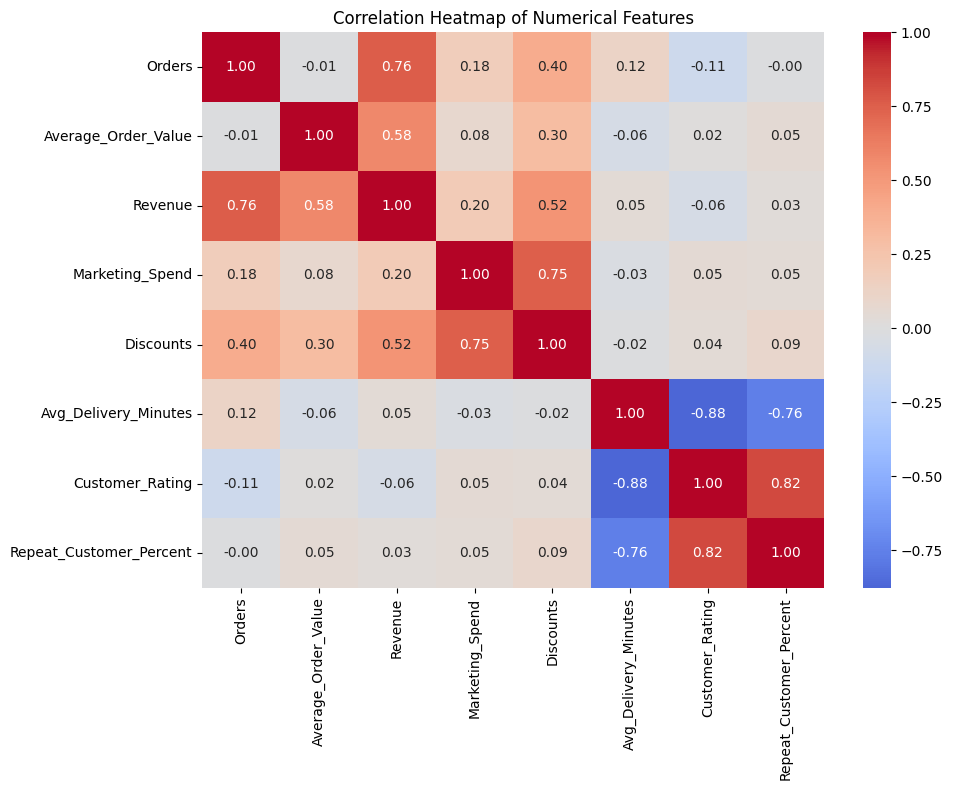

In [32]:
#heatmap for checking the correlation

fig, ax=plt.subplots(figsize=(10,8))

sns.heatmap(corr, annot=True, center=0, cmap='coolwarm', fmt='.2f', ax=ax)

ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

---
## Summary of Key Findings

- **Delivery speed is the biggest driver of customer satisfaction.** Average delivery minutes has a strong negative correlation (-0.88) with customer rating — by far the strongest relationship found in the dataset.
- **Orders and revenue both show seasonal peaks** around March-April, June, and December, rather than steady growth, which matters for staffing and inventory planning.
- **Location matters more than cuisine.** Average revenue varies by up to ~30% between the top city (Bengaluru) and the bottom city (Kochi), while the spread across cuisine types is much narrower.
- **Marketing spend has only a weak link to revenue** (correlation of about 0.20), suggesting spend alone isn't a reliable lever — it likely needs to be paired with other factors (city, channel, delivery speed) to move revenue meaningfully.
- **Order channel and weather have real but modest effects.** The App channel edges out Website and Partner Platform on customer rating, and Hot weather sees slightly more orders than Cloudy weather, but neither swings performance dramatically on its own.
- **Slow delivery likely hurts more than just ratings** — it's also negatively correlated with repeat customer percentage, pointing to a possible link between delivery speed and long-term customer retention.